# 第 12 章 · 蛋白序列位置对表征代码实验

本页用一个短蛋白片段的多序列对齐，观察哪些位置更保守，以及位置两两组合如何形成位置对表征。

[章节网页](../ch12.html)

## 运行内容

- 查看多序列对齐
- 计算位置保守性
- 绘制位置对表征

## 0. 序列对齐与位置对表征

先看多条同源序列怎样对齐，再看每一列的保守性。位置对表征把两个位置的保守性组合起来，作为结构预测中“位置对关系”的简化入口；本页不预测三维结构。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# AlphaFold 概念实验：先看多序列对齐，再把位置关系写成位置对表征。
sequence = "GIVEQCCTSICSLYQLENYCN"
msa = [
    "GIVEQCCTSICSLYQLENYCN",
    "GIVEQCCASVCSLYQLENYCN",
    "GIVEQCCTSVCSLYQLENFCN",
    "GLIEQCCTSICSLYQLDNYCN",
    "GIVEQACASVCSLYQLENFCN",
    "GVVEQCCTTICSLYQVENYCN",
    "GIVEQCCTSVCALYQLENHCN",
    "ALVEQCCASVCSLYQLENYCN",
]
msa_arr = np.array([list(row) for row in msa])
msa_df = pd.DataFrame(
    msa_arr,
    index=[f"序列{i + 1}" for i in range(len(msa))],
    columns=[f"{i + 1}" for i in range(len(sequence))],
)
conservation = []
for col in msa_arr.T:
    counts = Counter(col)
    conservation.append(counts.most_common(1)[0][1] / len(col))
conservation = np.array(conservation)
positions = np.arange(len(sequence))
sequence_gap = np.abs(positions[:, None] - positions[None, :])
locality_prior = np.exp(-sequence_gap / 7.0)
pair_repr = 0.70 * np.outer(conservation, conservation) + 0.30 * locality_prior
contact_prior = np.exp(-((sequence_gap - 7) ** 2) / 18.0)
contact_score = pair_repr * contact_prior
contact_score[sequence_gap < 3] = 0.0
np.fill_diagonal(contact_score, 0.0)

pair_rows = []
for i in range(len(sequence)):
    for j in range(i + 3, len(sequence)):
        pair_rows.append({
            "位置对": f"{i + 1}-{j + 1}",
            "氨基酸对": f"{sequence[i]}-{sequence[j]}",
            "序列间隔": j - i,
            "保守性乘积": conservation[i] * conservation[j],
            "位置对值": pair_repr[i, j],
            "候选接触分数": contact_score[i, j],
        })
pair_examples = pd.DataFrame(pair_rows).sort_values("位置对值", ascending=False).head(8).reset_index(drop=True)
contact_examples = pd.DataFrame(pair_rows).sort_values("候选接触分数", ascending=False).head(8).reset_index(drop=True)

pipeline_df = pd.DataFrame(
    [
        {"阶段": "MSA", "输出": f"{len(msa)} 条同源序列"},
        {"阶段": "保守性", "输出": "每个位置的最大频率"},
        {"阶段": "候选位置对", "输出": "保守性与序列间隔共同形成候选分数"},
        {"阶段": "候选接触", "输出": "从位置对表征中挑出最可能互相作用的位置"},
    ]
)
display(pipeline_df)
display(msa_df)
display(pd.DataFrame({"位置": range(1, len(sequence) + 1), "氨基酸": list(sequence), "保守性": conservation}).round(2))
display(pair_examples.round(3))
display(contact_examples[["位置对", "氨基酸对", "序列间隔", "候选接触分数"]].round(3))

,阶段,输出
0,MSA,8 条同源序列
1,保守性,每个位置的最大频率
2,候选位置对,保守性与序列间隔共同形成候选分数
3,候选接触,从位置对表征中挑出最可能互相作用的位置


,1,2,3,4,5,6,7,8,9,10,...,12,13,14,15,16,17,18,19,20,21
序列1,G,I,V,E,Q,C,C,T,S,I,...,S,L,Y,Q,L,E,N,Y,C,N
序列2,G,I,V,E,Q,C,C,A,S,V,...,S,L,Y,Q,L,E,N,Y,C,N
序列3,G,I,V,E,Q,C,C,T,S,V,...,S,L,Y,Q,L,E,N,F,C,N
序列4,G,L,I,E,Q,C,C,T,S,I,...,S,L,Y,Q,L,D,N,Y,C,N
序列5,G,I,V,E,Q,A,C,A,S,V,...,S,L,Y,Q,L,E,N,F,C,N
序列6,G,V,V,E,Q,C,C,T,T,I,...,S,L,Y,Q,V,E,N,Y,C,N
序列7,G,I,V,E,Q,C,C,T,S,V,...,A,L,Y,Q,L,E,N,H,C,N
序列8,A,L,V,E,Q,C,C,A,S,V,...,S,L,Y,Q,L,E,N,Y,C,N


,位置,氨基酸,保守性
0,1,G,0.88
1,2,I,0.62
2,3,V,0.88
3,4,E,1.00
4,5,Q,1.00
5,6,C,0.88
6,7,C,1.00
7,8,T,0.62
8,9,S,0.88
9,10,I,0.62


,位置对,氨基酸对,序列间隔,保守性乘积,位置对值,候选接触分数
0,18-21,N-N,3,1.0,0.895,0.368
1,11-14,C-Y,3,1.0,0.895,0.368
2,15-18,Q-N,3,1.0,0.895,0.368
3,4-7,E-C,3,1.0,0.895,0.368
4,14-18,Y-N,4,1.0,0.869,0.527
5,7-11,C-C,4,1.0,0.869,0.527
6,11-15,C-Q,4,1.0,0.869,0.527
7,13-18,L-N,5,1.0,0.847,0.678


,位置对,氨基酸对,序列间隔,候选接触分数
0,7-14,C-Y,7,0.810
1,13-20,L-C,7,0.810
2,11-18,C-N,7,0.810
3,4-11,E-C,7,0.810
4,14-21,Y-N,7,0.810
5,15-21,Q-N,6,0.783
6,14-20,Y-C,6,0.783
7,7-13,C-L,6,0.783


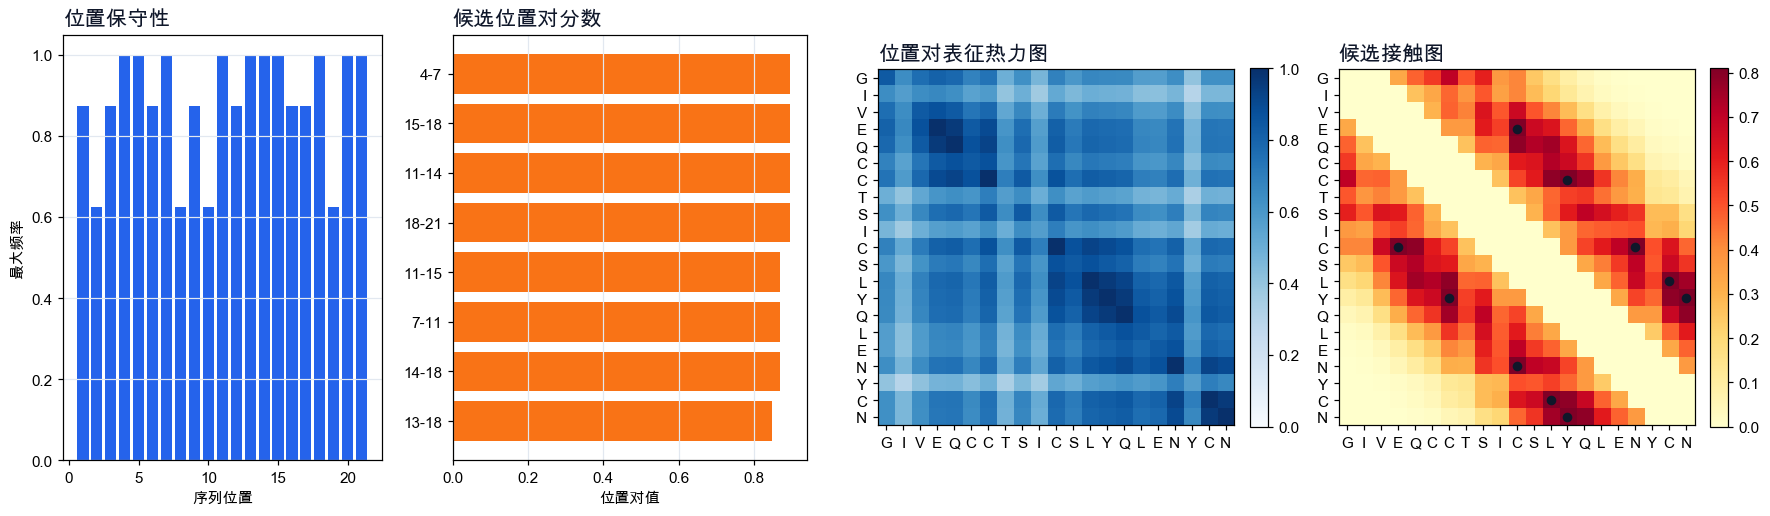

In [3]:
# 绘制位置保守性、候选位置对和候选接触图。
fig, axes = plt.subplots(1, 4, figsize=(16.2, 4.8), gridspec_kw={"width_ratios": [0.9, 1.0, 1.1, 1.1]})
axes[0].bar(range(1, len(sequence) + 1), conservation, color="#2563eb")
axes[0].set_title("位置保守性", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
axes[0].set_xlabel("序列位置")
axes[0].set_ylabel("最大频率")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, axis="y", color="#e2e8f0", linewidth=0.8)

top_pairs = pair_examples.sort_values("位置对值")
axes[1].barh(top_pairs["位置对"], top_pairs["位置对值"], color="#f97316")
axes[1].set_title("候选位置对分数", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
axes[1].set_xlabel("位置对值")
axes[1].grid(True, axis="x", color="#e2e8f0", linewidth=0.8)

im = axes[2].imshow(pair_repr, cmap="Blues", vmin=0, vmax=1)
axes[2].set_xticks(range(len(sequence)), list(sequence))
axes[2].set_yticks(range(len(sequence)), list(sequence))
axes[2].set_title("位置对表征热力图", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

im2 = axes[3].imshow(contact_score, cmap="YlOrRd", vmin=0, vmax=max(0.01, contact_score.max()))
axes[3].set_xticks(range(len(sequence)), list(sequence))
axes[3].set_yticks(range(len(sequence)), list(sequence))
axes[3].set_title("候选接触图", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
for _, row in contact_examples.head(5).iterrows():
    i, j = [int(x) - 1 for x in row["位置对"].split("-")]
    axes[3].scatter([j, i], [i, j], s=28, color="#0f172a")
fig.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()